In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df=pd.read_csv('data/StudentsPerformance.csv')
df.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## Seperating dependent and independent variables

In [72]:
X = df.drop('math score', axis=1)
y = df['math score']

## Using Column Transformer to perform One-Hot-Encoding and Standardization

In [73]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols= X.select_dtypes(exclude=['object']).columns


ss=StandardScaler()
ohe=OneHotEncoder()
ct=ColumnTransformer(
    [
        ('scaler', ss, numerical_cols),
        ('encoder', ohe, categorical_cols)
    ]
)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X_train_ct=ct.fit_transform(X_train)
X_test_ct=ct.transform(X_test)
pd.DataFrame(X_test_ct, columns=ct.get_feature_names_out()).head(5)


C:\Users\z1652\AppData\Local\Temp\ipykernel_16096\1365061881.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns


,scaler__reading score,scaler__writing score,encoder__gender_female,encoder__gender_male,encoder__race/ethnicity_group A,encoder__race/ethnicity_group B,encoder__race/ethnicity_group C,encoder__race/ethnicity_group D,encoder__race/ethnicity_group E,encoder__parental level of education_associate's degree,encoder__parental level of education_bachelor's degree,encoder__parental level of education_high school,encoder__parental level of education_master's degree,encoder__parental level of education_some college,encoder__parental level of education_some high school,encoder__lunch_free/reduced,encoder__lunch_standard,encoder__test preparation course_completed,encoder__test preparation course_none
0,1.137866,1.031032,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1,-0.245978,0.301391,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,0.238367,0.235060,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,0.515136,0.301391,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
4,0.930290,0.633046,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0


In [74]:
X_test_ct.shape, X_train_ct.shape


((200, 19), (800, 19))

## Training Differnt Model through Pipeline

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error

models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge(random_state=42)),
    ('DecisionTree', DecisionTreeRegressor(random_state=42)),
    ('RandomForest', RandomForestRegressor(random_state=42, n_estimators=100)),
    ('GradientBoosting', GradientBoostingRegressor(random_state=42, n_estimators=100))
]

results = []

for name, model in models:
    pipe = Pipeline([
        ('preprocessor', ct),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)

    for split_name, X_split, y_split in [('train', X_train, y_train), ('test', X_test, y_test)]:
        preds = pipe.predict(X_split)
        results.append({
            'model': name,
            'split': split_name,
            'r2': r2_score(y_split, preds),
            'rmse': root_mean_squared_error(y_split, preds)
        })

results_df = pd.DataFrame(results)
print(results_df.pivot(index='model', columns='split', values=['r2', 'rmse']))

                        r2                rmse          
split                 test     train      test     train
model                                                   
DecisionTree      0.747348  0.999653  7.840918  0.279508
GradientBoosting  0.872207  0.905040  5.576474  4.626939
LinearRegression  0.880433  0.874317  5.393994  5.323051
RandomForest      0.850393  0.976464  6.033663  2.303510
Ridge             0.880592  0.874304  5.390418  5.323321


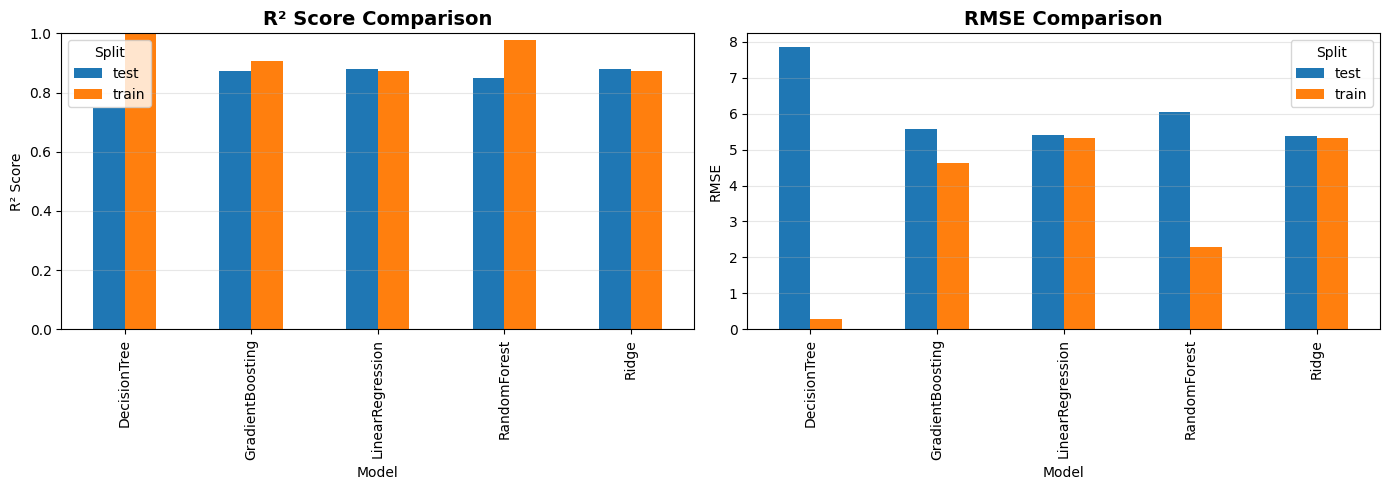

In [76]:
# Plot R² scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_pivot = results_df.pivot(index='model', columns='split', values='r2')
results_pivot.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'])
axes[0].set_title('R² Score Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_xlabel('Model')
axes[0].legend(title='Split')
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# Plot RMSE scores
rmse_pivot = results_df.pivot(index='model', columns='split', values='rmse')
rmse_pivot.plot(kind='bar', ax=axes[1], color=['#1f77b4', '#ff7f0e'])
axes[1].set_title('RMSE Comparison', fontsize=14, fontweight='bold')
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('Model')
axes[1].legend(title='Split')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

#### Overall we observe that Linear Regression, GradientBoost, and Ridge is performing well